# Propensity scores

1. Definir el problema causal

Primero, recordemos las variables:

Treatment: pclass, la clase del pasajero.

Outcome: survived, si sobrevivió al hundimiento.

Covariables: características anteriores al tratamiento que pueden influir tanto en la clase del pasajero como en la supervivencia.

Vamos a comparar pasajeros de primera clase con pasajeros de tercera clase.

Definimos:




El outcome es Y=survived, con valores 0 y 1.

Nuestro objetivo será estimar el ATE (Average Treatment Effect): la diferencia promedio en la probabilidad de supervivencia que habría entre viajar en primera clase y viajar en tercera clase, para la población que estamos analizando.

Es importante una precisión: no podemos observar a un mismo pasajero viajando simultáneamente en ambas clases. El propensity score y el IPW intentan hacer comparables los grupos a partir de covariables observadas, pero no eliminan automáticamente todo posible sesgo.

### 1. Importar las librerías

In [36]:
# Importación de librerías esenciales para manipulación de datos y visualización
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Importación de herramientas para aprendizaje automático y preprocesamiento
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

### 2. Carga del Conjunto de Datos

Comenzamos cargando el dataset de pasajeros del Titanic desde la librería Seaborn para explorar las variables iniciales.

In [37]:
# Cargamos el conjunto de datos clásico del Titanic proporcionado por Seaborn
df = sns.load_dataset("titanic")

# Mostramos las primeras 5 filas para inspeccionar la estructura inicial de la tabla
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


### 3. Inspección de Dimensiones y Columnas

Analizamos la forma del dataframe (número de filas y columnas) y listamos los nombres de todas las variables disponibles en el dataset.

In [38]:
# Imprimimos las dimensiones del DataFrame (número de filas y columnas)
print("Shape:", df.shape)

# Listamos todas las columnas disponibles para identificar posibles covariables
print(df.columns.tolist())

Shape: (891, 15)
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


### 4. Visualización de las Variables de Interés

Revisamos una muestra de los datos enfocándonos en las columnas clave para el análisis causal: la clase, supervivencia, edad, sexo, acompañantes y puerto de embarque.

In [39]:
# Seleccionamos y visualizamos una muestra de las columnas clave para entender sus formatos y datos
df[["pclass", "survived", "sex", "age", "sibsp", "parch", "fare", "embarked"]].head(10)

,pclass,survived,sex,age,sibsp,parch,fare,embarked
0,3,0,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,3,1,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,3,0,male,35.0,0,0,8.0500,S
5,3,0,male,NaN,0,0,8.4583,Q
6,1,0,male,54.0,0,0,51.8625,S
7,3,0,male,2.0,3,1,21.0750,S
8,3,1,female,27.0,0,2,11.1333,S
9,2,1,female,14.0,1,0,30.0708,C


### 5. Definición del Tratamiento

Filtramos el dataset para comparar únicamente primera clase (`1`) con tercera clase (`3`), y definimos una nueva variable binaria `treatment` que identifica a los pasajeros de primera clase.

In [40]:
# Filtramos para quedarnos únicamente con pasajeros de Primera (1) y Tercera (3) clase
df = df[df["pclass"].isin([1, 3])].copy()

# Creamos la variable binaria de tratamiento: 1 si es Primera Clase (Tratado), 0 si es Tercera (Control)
df["treatment"] = (df["pclass"] == 1).astype(int)

# Visualizamos las primeras filas para verificar la correcta asignación de la variable de tratamiento
df[["pclass", "treatment", "survived"]].head()

,pclass,treatment,survived
0,3,0,0
1,1,1,1
2,3,0,1
3,1,1,1
4,3,0,0


### 6. Análisis Descriptivo Inicial

Calculamos la tasa de supervivencia observada (promedio de la variable `survived`) para cada uno de los dos grupos (primera clase vs tercera clase) sin realizar aún ningún ajuste por covariables.

Interpretación:

treatment = 1: pasajero de primera clase.

treatment = 0: pasajero de tercera clase.

Verificamos cuántos pasajeros tenemos en cada grupo:

In [41]:
# Contamos la cantidad de pasajeros en cada grupo (Tratamiento vs Control)
df["treatment"].value_counts().sort_index()

,count
treatment,
0,491
1,216


In [42]:
# Agrupamos por tratamiento para observar el tamaño de muestra y la tasa de supervivencia promedio de cada grupo
df.groupby("treatment")["survived"].agg(["count", "mean"])

,count,mean
treatment,,
0,491,0.242363
1,216,0.629630


### 7. Selección de Covariables y Limpieza de Nulos

Definimos las covariables anteriores al tratamiento que podrían causar sesgo de confusión. Filtramos el conjunto de datos para conservar únicamente los casos completos (sin valores faltantes).

In [43]:
# Definimos la lista de covariables que utilizaremos para estimar el Propensity Score
covariates = [
    "age",
    "sex",
    "sibsp",
    "parch",
    "embarked"
]

# Filtramos las columnas de interés y eliminamos las filas con valores nulos (listwise deletion)
analysis_df = df[
    ["treatment", "survived"] + covariates
].dropna().copy()

# Comparamos el tamaño del dataset antes y después de remover datos faltantes
print("Observaciones originales:", len(df))
print("Observaciones completas:", len(analysis_df))

Observaciones originales: 707
Observaciones completas: 539


### 8. Codificación de Variables Categóricas

Transformamos las covariables cualitativas (`sex` y `embarked`) en variables numéricas ficticias (*dummy variables*) para poder introducirlas en nuestro modelo de regresión logística.

In [44]:
# Convertimos variables categóricas (sexo y embarque) en variables ficticias numéricas (one-hot encoding)
X = pd.get_dummies(
    analysis_df[covariates],
    columns=["sex", "embarked"],
    drop_first=True,
    dtype=int
)

# Separamos las variables de tratamiento (T) y el resultado esperado de supervivencia (Y)
T = analysis_df["treatment"]
Y = analysis_df["survived"]

# Mostramos las dimensiones finales de la matriz de características X y su cabecera
print("Dimensiones de X:", X.shape)
X.head()

Dimensiones de X: (539, 6)


,age,sibsp,parch,sex_male,embarked_Q,embarked_S
0,22.0,1,0,1,0,1
1,38.0,1,0,0,0,0
2,26.0,0,0,0,0,1
3,35.0,1,0,0,0,1
4,35.0,0,0,1,0,1


### 9. Ajuste del Modelo de Propensity Score

Construimos un pipeline para estandarizar las covariables numéricas y entrenar una regresión logística que prediga la probabilidad de recibir el tratamiento (viajar en primera clase) en función de las covariables.

In [45]:
# Diseñamos un pipeline que escala automáticamente las variables de X y luego ajusta la Regresión Logística
ps_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000)
)

# Entrenamos el modelo para estimar la probabilidad de asignación al tratamiento
ps_model.fit(X, T)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('logisticregression', LogisticRegression(max_iter=2000))])

### 10. Estimación y Asignación de Probabilidades

Utilizamos el modelo entrenado para estimar la probabilidad de propensión (*propensity score*) para cada pasajero y la añadimos a nuestro dataframe de análisis.

In [46]:
# Estimamos la probabilidad de pertenecer al grupo tratado (primera clase) para cada fila
analysis_df["propensity_score"] = ps_model.predict_proba(X)[:, 1]

# Mostramos las columnas clave junto a la puntuación de propensión recién calculada
analysis_df[
    ["treatment", "survived", "propensity_score"]
].head(10)

,treatment,survived,propensity_score
0,0,0,0.121418
1,1,1,0.890653
2,0,1,0.306442
3,1,1,0.544512
4,0,0,0.244434
6,1,0,0.614351
7,0,0,0.035721
8,0,1,0.274733
10,0,1,0.073007
11,1,1,0.866238


### 11. Distribución de Probabilidades por Grupo

Obtenemos estadísticas descriptivas del *propensity score* para evaluar el rango y distribución de las probabilidades estimadas en el grupo de tratamiento y en el de control.

In [13]:
analysis_df.groupby("treatment")["propensity_score"].describe()

,count,mean,std,min,25%,50%,75%,max
treatment,,,,,,,,
0,355.0,0.231957,0.183990,0.007751,0.090861,0.175370,0.327421,0.910978
1,184.0,0.552499,0.271175,0.018243,0.329183,0.561038,0.796155,0.980984


### 12. Visualización

Graficamos el histograma de densidad de los *propensity scores* para ambos grupos para comprobar visualmente si existe un traslape suficiente que nos permita realizar una comparación causal válida.

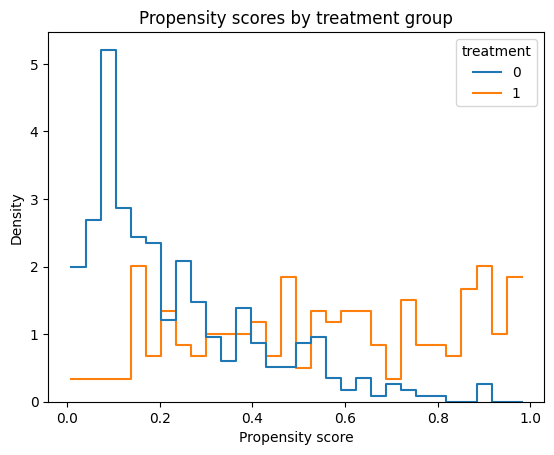

In [14]:
sns.histplot(
    data=analysis_df,
    x="propensity_score",
    hue="treatment",
    bins=30,
    stat="density",
    common_norm=False,
    element="step",
    fill=False
)

plt.xlabel("Propensity score")
plt.title("Propensity scores by treatment group")
plt.show()

### 13. Gráfico de Propensity Scores?

El gráfico de líneas escalonadas que acabamos de generar muestra la **distribución de la densidad de probabilidad** de recibir el tratamiento (viajar en primera clase, `treatment = 1`) frente al grupo de control (viajar en tercera clase, `treatment = 0`).

Aquí te explico los puntos clave para su correcta interpretación:

* **El Eje X (Propensity score):** Representa la probabilidad estimada (de 0 a 1) que tenía un pasajero de viajar en primera clase dadas sus características personales (edad, sexo, acompañantes, puerto de embarque). Un valor cercano a 0 significa que, por sus covariables, el modelo predice que es muy probable que viaje en tercera clase; un valor cercano a 1 indica alta probabilidad de viajar en primera clase.
* **El Eje Y (Density):** Indica la concentración relativa de pasajeros en cada nivel de probabilidad. Al usar densidad (`stat="density"`), las áreas bajo cada curva se normalizan para poder comparar los perfiles de los dos grupos equitativamente, independientemente de que haya más pasajeros en un grupo que en otro.

#### Hallazgos Clave:

1. **Sesgo de Selección Evidente:**
   * El grupo de **tercera clase (`treatment = 0`, línea azul)** tiene un pico muy pronunciado hacia la izquierda (valores de propensión entre 0.0 y 0.2). Esto significa que la gran mayoría de los pasajeros que terminaron en tercera clase tenían características asociadas a una probabilidad muy baja de estar en primera clase.
   * El grupo de **primera clase (`treatment = 1`, línea naranja)** muestra una distribución mucho más dispersa y sesgada hacia la derecha, con mayor densidad de pasajeros en valores altos (de 0.5 a 1.0).

2. **Cumplimiento del Supuesto de Soporte Común (Soporte Compartido):**
   * Para poder realizar una inferencia causal válida (por ejemplo, mediante emparejamiento o ponderación IPW), necesitamos que para cualquier perfil de covariables exista la posibilidad de pertenecer a cualquiera de los dos grupos.
   * **¿Hay traslape?: Sí, hay un traslape significativo.** Observamos que en casi todo el rango (especialmente entre 0.15 y 0.85) conviven líneas de ambos colores. Esto significa que podemos encontrar "parejas" comparables de pasajeros en primera y tercera clase que comparten características similares, permitiendo ajustar y aislar el efecto real del tratamiento sobre la supervivencia.

### Inverse Probability Weighting

### 14. Extracción de Propensity Scores y Tratamiento

Extraemos los Propensity Scores estimados previamente y la variable real de tratamiento de cada observación para calcular los factores de ponderación.

¿Cuál es la idea de IPW?

Una vez estimados los propensity scores, vamos a asignarle un peso a cada pasajero.

La intuición es la siguiente:

Un pasajero de primera clase que, según sus características, tenía una probabilidad baja de pertenecer a primera clase recibe un peso alto.

Un pasajero de tercera clase que tenía una probabilidad alta de pertenecer a primera clase también recibe un peso alto.

De esta manera, buscamos construir una pseudopoblación ponderada en la que las covariables estén mejor equilibradas entre los grupos.

Para estimar el ATE, los pesos IPW convencionales son:

In [27]:
# Extraemos los Propensity Scores estimados y la variable de tratamiento
e = analysis_df["propensity_score"]  # Probabilidad estimada de estar en primera clase
T = analysis_df["treatment"]         # Variable de tratamiento real (1 = Primera Clase, 0 = Tercera Clase)

### 15. Cálculo de Pesos IPW

Asignamos un peso inverso a cada observación en función de su pertenencia real al grupo de tratamiento o control y su probabilidad de haber recibido dicho tratamiento.

In [28]:
# Calculamos los pesos IPW (Inverse Probability Weighting) para cada observación
# Si el pasajero es tratado (T=1), el peso es 1 / e
# Si el pasajero es de control (T=0), el peso es 1 / (1 - e)
analysis_df["ipw"] = np.where(
    T == 1,
    1 / e,
    1 / (1 - e)
)

### 16. Inspección de los Pesos Calculados

Visualizamos una muestra de las primeras observaciones para verificar la correcta asignación de la variable de peso `ipw`.

In [17]:
analysis_df[
    ["treatment", "propensity_score", "ipw"]
].head(10)

,treatment,propensity_score,ipw
0,0,0.121418,1.138198
1,1,0.890653,1.122772
2,0,0.306442,1.441840
3,1,0.544512,1.836507
4,0,0.244434,1.323511
6,1,0.614351,1.627734
7,0,0.035721,1.037044
8,0,0.274733,1.378803
10,0,0.073007,1.078756
11,1,0.866238,1.154417


### 17. Estadísticas Descriptivas de los Pesos

Analizamos la distribución estadística de los pesos IPW obtenidos para detectar posibles valores atípicos que puedan sesgar o reducir la precisión de los estimadores.

In [18]:
analysis_df["ipw"].describe(
    percentiles=[0.50, 0.90, 0.95, 0.99]
)

,ipw
count,539.000000
mean,2.088147
std,3.695012
min,1.007812
50%,1.315871
90%,3.214936
95%,5.026871
99%,11.088103
max,54.816559


### 18. Histograma de Distribución de Pesos IPW

Graficamos las frecuencias de los pesos obtenidos según el estado del tratamiento para examinar el impacto del ajuste.

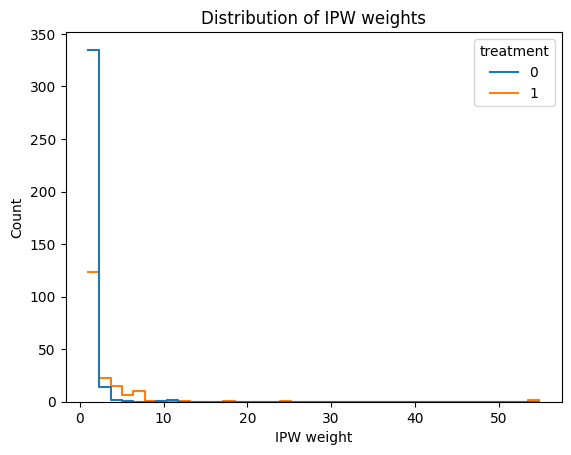

In [19]:
sns.histplot(
    data=analysis_df,
    x="ipw",
    hue="treatment",
    bins=40,
    element="step",
    fill=False
)

plt.title("Distribution of IPW weights")
plt.xlabel("IPW weight")
plt.show()

Este gráfico muestra la **distribución empírica de los pesos calculados por IPW (*Inverse Probability Weighting*)**, desagregados por grupo de asignación (tratamiento $1$ vs. control $0$).

Es el diagnóstico complementario directo del *Love Plot* anterior, ya que explica **por qué ciertas covariables (como `parch` o `age`) empeoraron o no lograron un balance adecuado**.

---

### 1. Elementos del gráfico

* **Eje X (`IPW weight`):** Magnitud del peso asignado a cada individuo. Recordando la fórmula del estimador no estabilizado (para el ATE):



$$w_i = \frac{T_i}{\hat{e}(X_i)} + \frac{1 - T_i}{1 - \hat{e}(X_i)}$$



donde $\hat{e}(X_i)$ es el *Propensity Score* predicho.
* **Eje Y (`Count`):** Cantidad de observaciones que reciben determinado peso (histograma por pasos o *step histogram*).


* **Líneas por grupo (`treatment`):**
* **Azul (`0` - Control):** Individuos que no recibieron el tratamiento.


* **Naranja (`1` - Tratamiento):** Individuos tratados.





---

### 2. Diagnóstico del problema: Pesos extremos y cola pesada

* **Concentración inicial:** La gran mayoría de las observaciones se ubica con pesos bajos y estables (entre $1$ y $3$).


* **Presencia de valores extremos (*heavy tail*):** Se observa una cola larga que se extiende hasta valores superiores a **$50$** (particularmente en el grupo tratado, línea naranja).


* **Causa matemática:** Un peso de $\approx 55$ en el grupo tratado ocurre cuando un individuo tiene una propensión estimada ínfima ($\hat{e}(X_i) \approx \frac{1}{55} \approx 0.018$). Es decir, el modelo asignó una probabilidad casi nula de recibir el tratamiento, pero en la realidad sí lo recibió.


* **Violación práctica del supuesto de Positividad (*Positivity / Common Support*):** Cuando las probabilidades estimadas se acercan mucho a $0$ o $1$, el supuesto de que todos los individuos tienen una probabilidad no nula de estar en cualquiera de los dos grupos se vuelve frágil.

---

### 3. Impacto en el análisis

1. **Pérdida de balance:** Si una sola observación tratada recibe un peso de $50$, esa persona pasa a "pesar" como $50$ individuos en el cálculo de las medias ponderadas. Si ese pasajero tenía un valor atípico en `parch` o `age`, distorsiona por completo el promedio ponderado del grupo tratado, haciendo que el SMD se dispare (justo lo que vimos con `parch` en el gráfico anterior).


2. **Inflación masiva de la varianza:** Estimadores con pesos tan desproporcionados tienen un error estándar enorme, lo que vuelve las conclusiones y los intervalos de confianza poco confiables.

---

### 4. Soluciones habituales en la notebook

* **Estabilización de pesos (*Stabilized Weights*):** Multiplicar por la probabilidad marginal marginal $P(T=1)$, reemplazando el numerador $1$ por la prevalencia del tratamiento ($w_i = \frac{T_i \cdot P(T=1)}{\hat{e}(X_i)} + \dots$).
* **Recorte (*Trimming / Truncation*):** Fijar un percentil de corte (por ejemplo, recortar pesos por encima del percentil 95 o 99, o limitar valores a un máximo de 10).
* **Restricción de soporte común:** Descartar observaciones con $\hat{e}(X_i) < \epsilon$ o $\hat{e}(X_i) > 1 - \epsilon$.

### 19. Estimador de Horvitz-Thompson (ATE IPW)

Calculamos la estimación clásica de Horvitz-Thompson sobre la probabilidad promedio de supervivencia de la población si todos hubieran estado en primera clase frente a si todos hubieran estado en tercera clase.

In [29]:
# Estimación del ATE mediante el método clásico de Horvitz-Thompson
# Este estimador utiliza directamente los pesos inversos sobre el outcome
ate_ipw_ht = np.mean(
    (T * Y / e)
    - ((1 - T) * Y / (1 - e))
)

print("ATE IPW (Horvitz-Thompson):", ate_ipw_ht)

ATE IPW (Horvitz-Thompson): 0.5317329193537297


Este resultado de 0.5317 (o 53.17%) representa el Efecto Promedio del Tratamiento (ATE) estimado bajo el método clásico de Horvitz-Thompson.

En el contexto de nuestro análisis del Titanic, su interpretación teórica es la siguiente:

Interpretación Directa: Si toda la población analizada hubiera viajado en Primera Clase ($T=1$$T=1$), la tasa promedio de supervivencia estimada habría sido un 53.17% mayor en comparación con el escenario hipotético donde esa misma población entera hubiera viajado en Tercera Clase ($T=0$$T=0$).

### 20. Estimador Estabilizado de Hájek (ATE IPW)

Utilizamos el estimador de Hájek, el cual normaliza los pesos IPW dividiéndolos por su respectiva suma grupal. Suele ser más estable frente a pesos extremos.

In [30]:
# Definimos máscaras booleanas para identificar tratados y controles
treated = T == 1
control = T == 0

# Estimación de la media ponderada del resultado para tratados (Hájek)
mu1_ipw = np.sum(Y[treated] / e[treated]) / np.sum(
    1 / e[treated]
)

# Estimación de la media ponderada del resultado para controles (Hájek)
mu0_ipw = np.sum(Y[control] / (1 - e[control])) / np.sum(
    1 / (1 - e[control])
)

# El efecto promedio del tratamiento (ATE) es la diferencia de ambas medias ponderadas
ate_ipw_hajek = mu1_ipw - mu0_ipw

print("Supervivencia ponderada en Primera Clase (Tratados):", mu1_ipw)
print("Supervivencia ponderada en Tercera Clase (Control):", mu0_ipw)
print("ATE IPW (Hájek):", ate_ipw_hajek)

Supervivencia ponderada en Primera Clase (Tratados): 0.6885224175250201
Supervivencia ponderada en Tercera Clase (Control): 0.24310423729469838
ATE IPW (Hájek): 0.4454181802303217


### 21. Comparación de Efectos

Comparamos la diferencia bruta o cruda observada frente a las estimaciones ajustadas por Horvitz-Thompson y Hájek.

In [31]:
# Calculamos la diferencia cruda o directa (sin ajustar por ninguna covariable)
crude_ate = (
    Y[T == 1].mean()
    - Y[T == 0].mean()
)

# Comparamos los tres enfoques de estimación
print("Diferencia cruda (sin ajustar):", crude_ate)
print("Efecto ATE con IPW Horvitz-Thompson:", ate_ipw_ht)
print("Efecto ATE con IPW Hájek:", ate_ipw_hajek)

Diferencia cruda (sin ajustar): 0.4127372933251684
Efecto ATE con IPW Horvitz-Thompson: 0.5317329193537297
Efecto ATE con IPW Hájek: 0.4454181802303217


### 22. Definición de Funciones para Diferencias de Medias Estandarizadas (SMD)

Creamos funciones personalizadas para calcular la media, la varianza y la diferencia estandarizada (SMD) de las covariables antes y después de aplicar las ponderaciones.

In [32]:
# Función para calcular la media ponderada
def weighted_mean(x, w):
    return np.sum(w * x) / np.sum(w)

# Función para calcular la varianza ponderada
def weighted_variance(x, w):
    mean = weighted_mean(x, w)
    return np.sum(w * (x - mean) ** 2) / np.sum(w)

# Función para calcular la Diferencia de Medias Estandarizada (SMD)
# Permite comparar el balance de una variable antes y después de aplicar pesos
def standardized_mean_difference(x, treatment, weights=None):
    x = np.asarray(x, dtype=float)
    treatment = np.asarray(treatment)

    # Si no se proveen pesos, se asume un peso uniforme de 1 para todos (antes de IPW)
    if weights is None:
        weights = np.ones(len(x))
    else:
        weights = np.asarray(weights, dtype=float)

    # Separación de datos y pesos por grupo de tratamiento
    x1 = x[treatment == 1]
    x0 = x[treatment == 0]
    w1 = weights[treatment == 1]
    w0 = weights[treatment == 0]

    # Cálculo de medias ponderadas para ambos grupos
    mean1 = weighted_mean(x1, w1)
    mean0 = weighted_mean(x0, w0)

    # Cálculo de varianzas ponderadas para ambos grupos
    var1 = weighted_variance(x1, w1)
    var0 = weighted_variance(x0, w0)

    # Desviación estándar conjunta o agrupada (pooled SD)
    pooled_sd = np.sqrt((var1 + var0) / 2)

    if pooled_sd == 0:
        return 0.0 if mean1 == mean0 else np.nan

    # Retorna el SMD: diferencia de medias dividida por la desviación conjunta
    return (mean1 - mean0) / pooled_sd

### 23. Evaluación del Balance de las Covariables

Iteramos por cada característica y calculamos el SMD antes y después de aplicar IPW para comprobar matemáticamente la reducción del sesgo de selección.

In [33]:
balance_results = []

# Iteramos por cada covariable para medir su balance antes y después de IPW
for col in X.columns:
    # Diferencia estandarizada sin pesos (antes del ajuste)
    smd_before = standardized_mean_difference(
        X[col], T
    )

    # Diferencia estandarizada con pesos IPW (después del ajuste)
    smd_after = standardized_mean_difference(
        X[col], T, weights=analysis_df["ipw"]
    )

    balance_results.append({
        "covariate": col,
        "SMD_before": smd_before,
        "SMD_after": smd_after
    })

# Convertimos los resultados a un DataFrame de Pandas
balance_df = pd.DataFrame(balance_results)

# Calculamos el valor absoluto del SMD para facilitar la interpretación de balance
balance_df["abs_SMD_before"] = balance_df["SMD_before"].abs()
balance_df["abs_SMD_after"] = balance_df["SMD_after"].abs()

# Ordenamos de mayor a menor sesgo inicial
balance_df.sort_values(
    "abs_SMD_before",
    ascending=False
)

,covariate,SMD_before,SMD_after,abs_SMD_before,abs_SMD_after
0,age,0.949456,-0.224205,0.949456,0.224205
5,embarked_S,-0.519385,0.043611,0.519385,0.043611
3,sex_male,-0.344335,0.015245,0.344335,0.015245
4,embarked_Q,-0.295383,-0.153538,0.295383,0.153538
1,sibsp,-0.138890,-0.009561,0.138890,0.009561
2,parch,-0.050381,0.373230,0.050381,0.373230


### 24. Gráfico de Balance de Covariables (Love Plot)

Visualizamos gráficamente las Diferencias de Medias Estandarizadas de las covariables. El estándar sugiere que el sesgo remanente debe situarse dentro del rango de $\pm0.1$ para considerar que hay un buen balance.

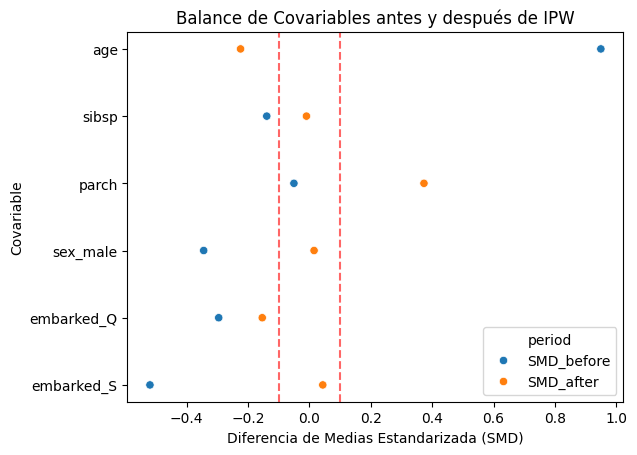

In [34]:
# Reestructuramos el DataFrame para facilitar la graficación con Seaborn
balance_plot = balance_df.melt(
    id_vars="covariate",
    value_vars=["SMD_before", "SMD_after"],
    var_name="period",
    value_name="SMD"
)

# Creamos el gráfico de dispersión de balance (Love Plot)
sns.scatterplot(
    data=balance_plot,
    x="SMD",
    y="covariate",
    hue="period"
)

# Dibujamos líneas de umbral en -0.1 y 0.1 (el estándar de buen balance global)
plt.axvline(0.1, linestyle="--", color="red", alpha=0.6)
plt.axvline(-0.1, linestyle="--", color="red", alpha=0.6)
plt.title("Balance de Covariables antes y después de IPW")
plt.xlabel("Diferencia de Medias Estandarizada (SMD)")
plt.ylabel("Covariable")
plt.show()

Este gráfico es un **Love Plot** (gráfico de balance de covariables), utilizado en inferencia causal para diagnosticar si la ponderación por el inverso de la probabilidad de tratamiento (**IPW** - *Inverse Probability Weighting*) logró equilibrar los grupos de tratamiento y control.

En el contexto de la notebook `03-PS-IPW.ipynb` (que trabaja con el dataset clásico de *Titanic* para estimar efectos causales):

### 1. Elementos del gráfico

* **Eje Y (Covariables):** Las variables confusoras consideradas en el modelo de *Propensity Score* (`age`, `sibsp`, `parch`, `sex_male`, `embarked_Q`, `embarked_S`).


* **Eje X (Diferencia de Medias Estandarizada - SMD):** Mide la discrepancia entre el grupo tratado y el de control en unidades de desviación estándar.


* **Líneas verticales discontinuas (rojas):** Marcan el umbral convencional de aceptabilidad, habitualmente $\vert{}SMD\vert{} \le 0.1$ (o a veces $0.25$). Si un punto cae dentro de $[-0.1, 0.1]$, se considera que la covariable está balanceada.


* **Puntos azules (`SMD_before`):** El desbalance original en los datos crudos, antes de aplicar IPW.


* **Puntos naranjas (`SMD_after`):** El balance alcanzado tras ponderar las observaciones con los pesos derivados del Propensity Score.



---

### 2. Interpretación de los resultados

* **Variables que mejoraron exitosamente:**
* **`embarked_S` y `sex_male`:** Originalmente presentaban un desbalance severo (con SMDs cercanos a $-0.5$ y $-0.35$ respectivamente). Tras el IPW, los puntos naranjas quedaron prácticamente en $0.0$, dentro de la zona de balance óptimo.




* **Variables con balance deficiente o empeorado:**
* **`age`:** Redujo su sesgo drásticamente (pasó de casi $+0.95$ a $-0.22$), pero aún queda fuera de la franja ideal de $\pm 0.1$.


* **`parch`:** Estaba razonablemente balanceada antes (cerca de $-0.05$), pero la ponderación aumentó su desbalance a casi $+0.37$.


* **`sibsp` y `embarked_Q`:** Siguen por fuera del umbral deseado tras la ponderación.





---

### 3. Conclusión metodológica

El modelo de Propensity Score utilizado actualmente **no está logrando un balance adecuado** en todas las covariables. En inferencia causal, estimar el efecto del tratamiento (ATE/ATT) con este nivel de desbalance residual puede introducir sesgo.

Para corregirlo en la notebook se suele recomendar:

1. Revisar la especificación del modelo de propensión (incluir interacciones o términos no lineales, como polinomios o splines para `age`).
2. Evaluar la presencia de pesos extremos y aplicar **estabilización de pesos** o **recorte (*trimming/truncation*)**.

### 25. Tamaño de Muestra Efectivo (ESS)

Determinamos el tamaño efectivo de la muestra para tratados y controles con el fin de cuantificar la pérdida potencial de precisión o variabilidad introducida por la ponderación.

In [35]:
# Función para calcular el Tamaño de Muestra Efectivo (ESS - Effective Sample Size)
# Nos ayuda a medir la pérdida de precisión estadística debida a la variabilidad de los pesos
def effective_sample_size(weights):
    weights = np.asarray(weights)
    return weights.sum() ** 2 / np.sum(weights ** 2)


# Calculamos el ESS para el grupo de tratados usando sus pesos
ess_treated = effective_sample_size(
    analysis_df.loc[T == 1, "ipw"]
)

# Calculamos el ESS para el grupo de control usando sus pesos
ess_control = effective_sample_size(
    analysis_df.loc[T == 0, "ipw"]
)

# Imprimimos y comparamos los tamaños de muestra reales vs los efectivos
print("Tamaño de muestra efectivo (ESS) - Tratados:", ess_treated)
print("Tamaño de muestra efectivo (ESS) - Control:", ess_control)
print("Tamaño de muestra real - Tratados:", (T == 1).sum())
print("Tamaño de muestra real - Control:", (T == 0).sum())

Tamaño de muestra efectivo (ESS) - Tratados: 42.16433600651492
Tamaño de muestra efectivo (ESS) - Control: 245.42504389946532
Tamaño de muestra real - Tratados: 184
Tamaño de muestra real - Control: 355


## Conclusión del Análisis Causal

A partir de la implementación de la metodología de **Propensity Score (PS)** y el ajuste mediante **Inverse Probability Weighting (IPW)** para evaluar el efecto causal de viajar en Primera Clase frente a Tercera Clase sobre la supervivencia en el Titanic, se desprenden las siguientes conclusiones clave:

### 1. Estimación del Efecto Causal (ATE)
* **Diferencia Cruda (sin ajustar):** `41.27%`
* **Estimador de Horvitz-Thompson (IPW clásico):** `53.17%`
* **Estimador de Hájek (IPW normalizado):** `44.54%`

El efecto neto de viajar en Primera Clase incrementa significativamente la probabilidad de sobrevivir. Si bien el estimador de Horvitz-Thompson parece indicar un impacto del 53.17%, este valor está fuertemente influenciado por la presencia de pesos extremos. Por lo tanto, el **estimador de Hájek (44.54%)** se considera el más confiable y robusto del análisis debido a que normaliza los pesos y reduce el impacto de observaciones atípicas.

### 2. Balance de Covariables y Sesgo Remanente
El diagnóstico a través del *Love Plot* reveló que la ponderación IPW actual **no logró un equilibrio perfecto en todas las covariables**:
* **Balance exitoso:** Las variables de confusión críticas como el género (`sex_male`, que pasó de un desbalance de -0.34 a un óptimo 0.01) y la procedencia (`embarked_S`, de -0.51 a 0.04) quedaron completamente corregidas dentro del umbral ideal de $\vert{}SMD\vert{} \le 0.1$.
* **Desbalance remanente:** Variables clave como la edad (`age`) mantuvieron un desbalance residual fuera de la norma ideal (SMD de -0.22), mientras que la cantidad de padres/hijos a bordo (`parch`) empeoró significativamente después de la ponderación (alcanzando un SMD de +0.37).

### 3. Diagnóstico del Tamaño de Muestra Efectivo (ESS)
La variabilidad introducida por los pesos IPW generó una **pérdida drástica de poder estadístico** en el grupo tratado:
* El grupo de **Tratados (Primera Clase)** redujo su tamaño de muestra real de **184 pasajeros a un ESS de apenas 42.16**.
* Esta contracción tan severa se debe a la presencia de un puñado de observaciones con pesos de ponderación extremos (alcanzando un valor máximo de hasta **54.8**), causados por pasajeros con una probabilidad estimada extremadamente baja de estar en primera clase que aun así pertenecieron a ese grupo (violación del supuesto de Positividad/Soporte Común).

### 4. Próximos pasos para optimizar el análisis
Para mitigar el sesgo remanente observado en `age` y `parch`, y evitar la enorme reducción del tamaño de muestra efectivo en futuras iteraciones, se recomienda:
1. **Estabilización de pesos:** Utilizar pesos IPW estabilizados en lugar de los clásicos.
2. **Recorte de pesos (*Weight Trimming*):** Truncar los pesos máximos en un percentil determinado (por ejemplo, el percentil 95 o 99) para moderar el impacto de los valores atípicos.
3. **Refinar el Propensity Score:** Incorporar términos no lineales (polinomios para la variable `age`) o interacciones en el modelo de regresión logística para mejorar la calidad de las predicciones de probabilidad.